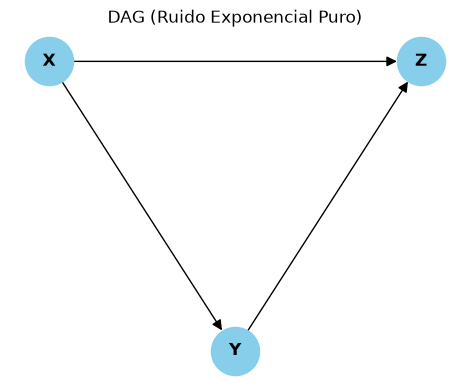


INICIANDO EXPERIMENTO PARA N = 100
 -> Entrenando MSE para N=100...
Using device: cpu
Early stopping at step 58
Using device: cpu
Early stopping at step 72
 -> Entrenando HSIC para N=100...
Using device: cpu
Early stopping at step 46
Using device: cpu
Early stopping at step 11
 -> Entrenando HYBRID_ALPHA0.1 para N=100...
Using device: cpu
Early stopping at step 40
Using device: cpu
Early stopping at step 124
 -> Entrenando HYBRID_ALPHA0.2 para N=100...
Using device: cpu


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# BLOQUES 2 y 3 REESTRUCTURADOS: EVALUACIÓN MULTI-N CON MAE (CORREGIDO)
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import time
import numpy as np
import re
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: DEFINICIÓN DE FUNCIONES AUXILIARES PARA EVITAR NAMEERROR] ---

def generate_synthetic_triangle_data_pure_gausian (num_samples=2000, seed=42, escala=1.0):
    """Genera el SCM No Lineal con ruido Gausiano Puro."""
    np.random.seed(seed)
    eps_X = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Y = np.random.exponential(scale=escala, size=num_samples) - escala
    eps_Z = np.random.exponential(scale=escala, size=num_samples) - escala
    
    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuración de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACIÓN DEL EXPERIMENTO] ---

# Definimos los tamaños de muestra (N) que queremos auditar
valores_N_experimento = [50, 100, 300,500, 700, 1000]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)
semillas_experimento = list(range(1, 11))  # Ejecutar el experimento con 10 semillas distintas

# Estructura del Grafo Causal Criterio
graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])

# Mapeo de tipos continuos para la KAN
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# Dibujar el DAG estructural para la documentación de tu TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue', font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Exponencial Puro)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACIÓN] ---

for seed in semillas_experimento:
    print(f"\n" + "#"*70)
    print(f"INICIANDO EXPERIMENTO PARA SEMILLA = {seed}")
    print("#"*70)

    for N_actual in valores_N_experimento:
        print(f"\n" + "="*70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("="*70)
        
        # 1. Generación de datos escalada al N actual
        data_triangle = generate_synthetic_triangle_data_pure_gausian(num_samples=N_actual, seed=seed, escala=1.0)
        factual_train_d, factual_eval_d = train_test_split(data_triangle, test_size=0.5, random_state=42)
        
        datos_reales_test = factual_eval_d[['X', 'Y', 'Z']].to_numpy()
        num_muestras_eval = len(factual_eval_d)
        
        # 2. Definición de las estrategias (Baselines + Híbridos)
        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a,2)}" for a in valores_alpha_candidatos if a != 0.0 and a != 1.0]
        
        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)
                
            # Llamada segura con argumentos locales pasados explícitamente
            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )
            
            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)
            
            # 3. Diagnóstico en el conjunto de evaluación de este N
            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
            fila = {'Conf': conf_name, 'Alpha': alpha_val, 'Beta': beta_val, 'N': N_actual, 'Seed': seed}
            
            try:
                if hasattr(model, 'get_residuals'):
                    residuos = model.get_residuals(factual_eval_d)
                    X_test = factual_eval_d['X'].to_numpy().flatten()
                    Y_test = factual_eval_d['Y'].to_numpy().flatten()
                    sistema_residuos = [X_test]
                    
                    if 'Y' in residuos and residuos['Y'] is not None:
                        rY = preparar_residuo(residuos['Y'])
                        sistema_residuos.append(rY)
                        fila['MSE Y'] = round(float(np.mean(rY**2)), 5)
                        fila['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                        fila['HSIC(Y,X)'] = round(float(HSIC(rY, X_test)), 5)
                        
                    if 'Z' in residuos and residuos['Z'] is not None:
                        rZ = preparar_residuo(residuos['Z'])
                        sistema_residuos.append(rZ)
                        fila['MSE Z'] = round(float(np.mean(rZ**2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_test)), 5)
                        fila['HSIC(Z,Y)'] = round(float(HSIC(rZ, Y_test)), 5)
                    
                    fila['dHSIC Total'] = round(float(max(0.0, dHSIC(*sistema_residuos))), 5)

                if hasattr(model, 'draw_samples'):
                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[['X', 'Y', 'Z']].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

            except Exception as e:
                print(f"   [Error en evaluación] {conf_name} con N={N_actual}: {e}")
                
            registros_tabla_final.append(fila)

# --- [PASO 4: CONSTRUCCIÓN DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(by=['N', 'es_hibrido', 'Alpha'], ascending=[True, True, False]).drop(columns=['es_hibrido'])

print("\n--- MATRIZ DE DIAGNÓSTICO MULTI-N FINALIZADA ---")
display(df_final_multi_n)

# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
ruta_archivo = os.path.join(carpeta_tablas, "aditivo_exponencial_2.csv")

# Crear la carpeta si no existe
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

# Guardar el DataFrame
df_final_multi_n.to_csv(ruta_archivo, index=False)

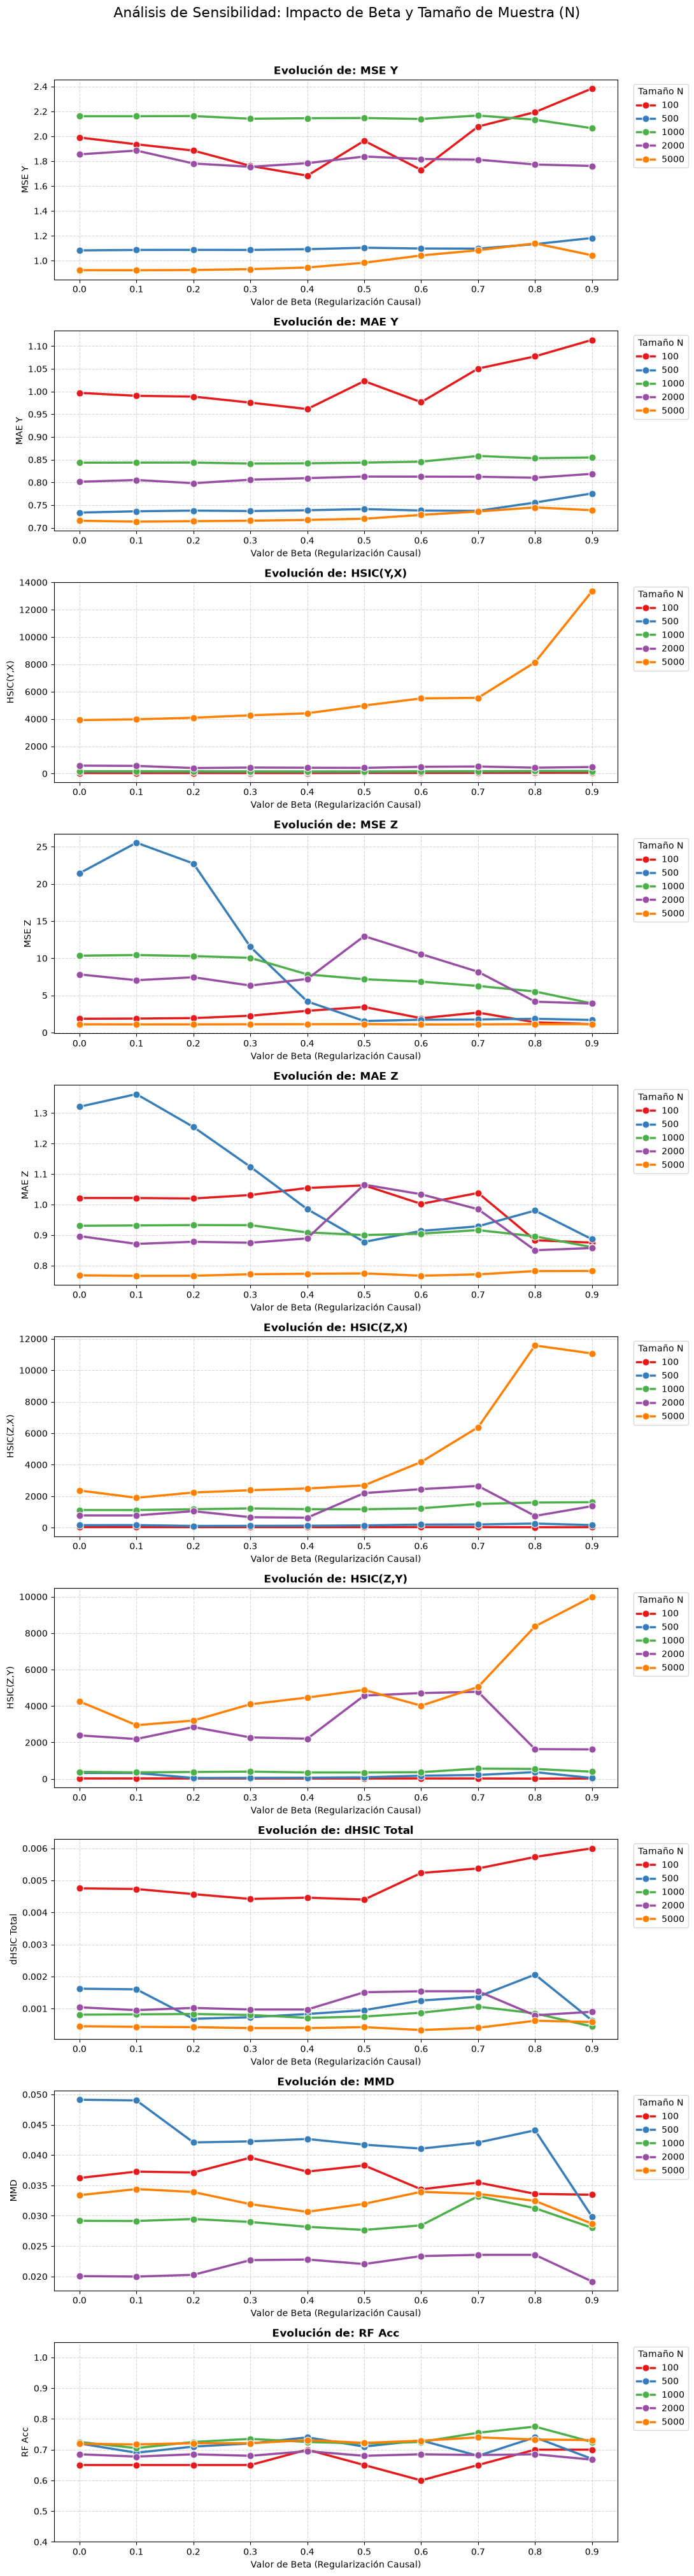

In [6]:
# ==============================================================================
# BLOQUE 4: VISUALIZACIÓN DE SENSIBILIDAD MULTI-N (COLORES POR MUESTRA)
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_sensibilidad_multi_n(df):
    # 1. FILTRADO DE CONTROL: Excluimos el modelo 'HSIC' puro para limpiar las escalas Y
    df_to_plot = df[df['Conf'] != 'HSIC'].copy()
    
    # 2. IDENTIFICACIÓN DE MÉTRICAS: Detectamos las columnas a graficar (incluyendo MAE)
    excluidas = ['Conf', 'Alpha', 'Beta', 'N']
    metricas = [c for c in df_to_plot.columns if c not in excluidas]
    
    # 3. PALETA DE COLORES FIJA: Asignamos un color único a cada valor de N
    lista_n = sorted(df_to_plot['N'].unique())
    colores_n = sns.color_palette("Set1", len(lista_n))
    paleta_mapeo = dict(zip(lista_n, colores_n))
    
    # 4. CONFIGURACIÓN DE LA FIGURA (Un subgráfico vertical por métrica)
    num_plots = len(metricas)
    fig, axes = plt.subplots(num_plots, 1, figsize=(11, 4 * num_plots), sharex=False)
    fig.suptitle('Análisis de Sensibilidad: Impacto de Beta y Tamaño de Muestra (N)', fontsize=16, y=1.01)
    
    # Asegurar que axes sea una lista iterable incluso si solo hay una métrica
    if num_plots == 1: axes = [axes]
    
    # 5. BUCLE DE DIBUJO
    for i, metrica in enumerate(metricas):
        ax = axes[i]
        
        # Graficamos el eje X (Beta) vs el eje Y (Métrica), separando por colores según 'N'
        sns.lineplot(data=df_to_plot, x='Beta', y=metrica, hue='N', palette=paleta_mapeo,
                     marker='o', markersize=8, linewidth=2.5, ax=ax)
        
        # Ajuste visual específico para la precisión del Random Forest
        if 'RF Acc' in metrica:
            ax.set_ylim(0.4, 1.05) # Permite evaluar visualmente el margen sobre el azar (0.5)
            
        # Forzar que el eje X muestre exactamente tus valores probados de Beta
        valores_beta = sorted(df_to_plot['Beta'].unique())
        ax.set_xticks(valores_beta)
        
        # Estética de cada panel
        ax.set_title(f"Evolución de: {metrica}", fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=10)
        ax.set_xlabel("Valor de Beta (Regularización Causal)", fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Posicionar la leyenda fuera del gráfico para evitar que tape los datos
        ax.legend(title="Tamaño N", bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()

    if not os.path.exists('plots'):
        os.makedirs('plots')
    plt.savefig('plots/aditivo_exponencial_1.png', dpi=300, bbox_inches='tight')
    plt.show()

# Ejecutar la visualización comparativa
plot_sensibilidad_multi_n(df_final_multi_n)